In [1]:
import matplotlib.pyplot as plt
import numpy.typing as npt
from pathlib import Path
import pandas as pd
import numpy as np
import re

# Ahora importa el módulo
from RRAM.Representate import config_ax, setup_paper_plt

setup_paper_plt(plt, latex=True, scaling=2.25)

#### V_Reset de las curvas experimentales

In [2]:
# Rutas de los archivos
ruta_datos = Path.cwd() / "Datos_Experimentales" / "Medidas_Experimentales_RRAM"
ruta_figuras = Path.cwd() / "Datos_Experimentales" / "V_Reset"
output_data_filename= "V_reset_experimental.txt"

ruta_figuras.mkdir(exist_ok=True)

# Listar todos los archivos
archivos = []
for archivo in ruta_datos.glob("Cycle_n_*.txt"):
    # Buscar el número dentro del nombre (después de "Cycle_n_")
    match = re.fullmatch(r"Cycle_n_(\d{3,4})\.txt", archivo.name)
    # match = re.fullmatch(r"Cycle_n_(1000|[1-9][0-9]{0,2})\.txt", archivo.name)
    if match:
        numero = int(match.group(1))  # convertir a entero
        if 100 <= numero <= 1300:  # aplicar filtro de rango
            archivos.append(archivo)

print(f"Archivos encontrados: {len(archivos)}")
print(archivos)


Archivos encontrados: 1201
[WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_100.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_1000.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_1001.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_1002.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_1003.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_1004.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Medidas_Experimentales_RRAM/Cycle_n_1005.txt'), WindowsPath('c:/Users/Usuario/Documents/GitHub/RR

In [3]:
def plot_iv_and_derivative(
    voltaje, intensidad, dI_dV, top_indices, ruta_figuras, **kwargs
):
    """
    Plots the I-V curve and its derivative, highlighting specific points with the highest derivative values.
    Parameters:
    -----------
    V_set : array-like
        Array of voltage values (x-axis data).
    I_set : array-like
        Array of current values corresponding to the voltage values (y-axis data for the I-V curve).
    dI_dV : array-like
        Array of derivative values (y-axis data for the derivative plot).
    top_indices : list of int
        Indices of the points with the highest derivative values to be highlighted on the plots.
    ruta_figuras : str
        File path where the generated figure will be saved.
    Returns:
    --------
    None
        The function saves the generated plot as an image file at the specified location.
    Notes:
    ------
    - The function creates a figure with two subplots:
        1. The I-V curve with logarithmic scaling on the y-axis.
        2. The derivative of the I-V curve.
    - Points with the highest derivative values are highlighted in red on both subplots.
    - The figure is saved as an image file in the specified path with a resolution of 300 dpi.
    """

    # Verificar si se pasó un DataFrame
    df = kwargs.get("df", None)
    
    # Crear una figura con dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # === Configuración de estilo LaTeX y plot ===
    setup_paper_plt(plt, latex=True, scaling=2.5)

    config_ax(ax1)
    config_ax(ax2)

    if df is not None:
        voltage_completo = df["Voltaje"]
        current_completo = abs(df["Corriente"])

        # En el primer subplot, graficar la curva I-V
        ax1.plot(abs(voltage_completo), current_completo, "b-", linewidth=2)
        ax1.set_xlabel(r"|Voltaje| (\si{\volt})")
        ax1.set_ylabel(r"Corriente (\si{\ampere})")
        ax1.set_title("Curva I-V")
        ax1.set_yscale("log")
        ax1.grid(True)
        
    else:
        # En el primer subplot, graficar la curva I-V
        ax1.plot(abs(voltaje), intensidad, "b-", linewidth=2)
        ax1.set_xlabel(r"|Voltaje| (\si{\volt})")
        ax1.set_ylabel(r"Corriente (\si{\ampere})")
        ax1.set_title("Curva I-V")
        ax1.set_yscale("log")
        ax1.grid(True)
        
        
    # Solo marcar los puntos con mayor derivada en el primer subplot
    for idx in top_indices:
        ax1.plot(abs(voltaje[idx]), intensidad[idx], "o", markersize=6, color="red")
        ax1.annotate(
            f"{abs(voltaje[idx]):.2f} V",
            (abs(voltaje[idx]), intensidad[idx]),
            textcoords="offset points",
            xytext=(-35, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )

    # En el segundo subplot, graficar la derivada de la corriente respecto al voltaje
    ax2.plot(abs(voltaje), dI_dV, "-", linewidth=2, color="blue")
    ax2.set_xlabel(r"|Voltaje| (\si{\volt})")
    ax2.set_ylabel(r"$\dv{I}{V}$ (\si{\ampere/\volt})")
    ax2.set_title("Derivada de la curva I-V")
    ax2.grid(True)

    # Solo marcar los puntos con mayor derivada en el segundo subplot
    for idx in top_indices:
        ax2.plot(abs(voltaje[idx]), dI_dV[idx], "o", markersize=6, color="red")
        ax2.annotate(
            f"{abs(voltaje[idx]):.2f} V",
            (abs(voltaje[idx]), dI_dV[idx]),
            textcoords="offset points",
            xytext=(-25, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )

    fig.savefig(str(ruta_figuras) + ".pdf", dpi=300, bbox_inches="tight")  # type: ignore
    plt.close(fig)

    # Crear figura combinada con eje secundario
    fig_combinada, ax_comb_1 = plt.subplots(figsize=(12, 9))

    # === Configuración de la figura combinada ===
    
    setup_paper_plt(plt, latex=True, scaling=2)
    config_ax(ax_comb_1)

    if df is not None:
        voltage_completo = df["Voltaje"]
        current_completo = abs(df["Corriente"])

        # ---- Eje izquierdo (Corriente) ----
        ax_comb_1.semilogy(
            abs(voltage_completo),
            current_completo,
            "o-",
            color="blue",
            label=r"Corriente (\si{\ampere})",
        )
        ax_comb_1.set_xlabel(r"|Voltaje| (\si{\volt})")
        ax_comb_1.set_ylabel(r"Corriente (\si{\ampere})", color="blue")
        ax_comb_1.tick_params(axis="y", labelcolor="blue")
    
    else:
        # ---- Eje izquierdo (Corriente) ----
        ax_comb_1.semilogy(
            abs(voltaje), 
            intensidad, 
            "o-", 
            color="blue", 
            label=r"Corriente (\si{\ampere})"
        )
        ax_comb_1.set_xlabel(r"|Voltaje| (\si{\volt})")
        ax_comb_1.set_ylabel(r"Corriente (\si{\ampere})", color="blue")
        ax_comb_1.tick_params(axis="y", labelcolor="blue")

    # Solo marcar los puntos con mayor derivada en el primer subplot
    for idx in top_indices:
        ax_comb_1.plot(abs(voltaje[idx]), intensidad[idx], "o", markersize=6, color="red")
        ax_comb_1.annotate(
            f"{abs(voltaje[idx]):.2f} V",
            (abs(voltaje[idx]), intensidad[idx]),
            textcoords="offset points",
            xytext=(-35, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )

    # ---- Eje derecho (Derivada) ----
    ax_comb_2 = ax_comb_1.twinx()  # Crear un eje Y secundario
    config_ax(ax2)
    ax_comb_2.plot(
        abs(voltaje), dI_dV, "o-", color="orange", label=r"$\dv{I}{V}$ (\si{\ampere/\volt})"
    )
    ax_comb_2.set_ylabel(r"$\dv{I}{V}$ (\si{\ampere/\volt})", color="orange")
    ax_comb_2.tick_params(axis="y", labelcolor="orange")

    # Solo marcar los puntos con mayor derivada en el segundo subplot
    for idx in top_indices:
        ax_comb_2.plot(abs(voltaje[idx]), dI_dV[idx], "o", markersize=6, color="green")
        ax_comb_2.annotate(
            f"{abs(voltaje[idx]):.2f} V",
            (abs(voltaje[idx]), dI_dV[idx]),
            textcoords="offset points",
            xytext=(-25, -5),
            ha="center",
            fontsize=16,
            fontweight="bold",
        )

    # Leyendas combinadas
    lines1, labels1 = ax_comb_1.get_legend_handles_labels()
    lines2, labels2 = ax_comb_2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    plt.title("I-V y su Derivada")

    fig_combinada.savefig(
        str(ruta_figuras) + "_combinado.png", dpi=300, bbox_inches="tight"
    )  # type: ignore
    plt.close(fig_combinada)

In [4]:
def obtener_V_reset_Derivada(ruta_datos, num_valores_maximos=3):
    """
    Analiza un archivo de datos experimentales para calcular la derivada de la corriente
    con respecto al voltaje, identifica los valores máximos de la derivada y genera una
    gráfica de los datos.
    Args:
        ruta_datos (Path): Ruta al archivo que contiene los datos experimentales.
            El archivo debe existir y contener tres columnas: "Voltaje", "Corriente" y "tiempo".
        num_valores_maximos (int, opcional): Número de valores máximos de la derivada a extraer.
            Por defecto es 5.
    Returns:
        dict: Un diccionario con las siguientes claves:
            - "top_derivadas" (np.ndarray): Los valores máximos de la derivada numérica.
            - "top_voltajes" (np.ndarray): Los voltajes correspondientes a los valores máximos
              de la derivada.
    Raises:
        FileNotFoundError: Si el archivo especificado en `ruta_datos` no existe.
    Notas:
        - La función filtra los datos para considerar solo las primeras 111 filas del archivo.
        - Genera una gráfica que muestra la curva IV y la derivada, y la guarda en una
          subcarpeta "Datos_Experimentales/V_Set" con un nombre basado en el archivo de entrada.
    """
    # Verificar que el archivo existe
    if not ruta_datos.exists():
        raise FileNotFoundError(
            f"El archivo {ruta_datos} no existe. Verificar la ruta."
        )

    # Cargar datos experimentales
    data_set = np.loadtxt(ruta_datos)

    # Crear el DataFrame
    df_set = pd.DataFrame(data_set, columns=["Voltaje", "Corriente", "tiempo"])
    df_set = df_set.iloc[0:140]

    # Combinación de ambos filtros
    # Primero, resetea los índices después del filtrado
    df_set_filtrado = df_set.loc[
        (df_set["Voltaje"] >= -1.4) & (df_set["Voltaje"] <= -0.1)
    ].reset_index(drop=True)

    # Calcular la derivada numérica de la corriente con respecto al voltaje
    dI_dV = np.gradient(
        np.log10(abs(df_set_filtrado["Corriente"])), df_set_filtrado["Voltaje"]
    )

    # Extraer los índices de los valores máximos
    indices_maximos = np.argsort(dI_dV)[-num_valores_maximos:]

    # Extraer los valores máximos y sus voltajes correspondientes
    max_derivative_values = dI_dV[indices_maximos]
    top_voltages = df_set_filtrado["Voltaje"].values[indices_maximos]

    V_set = df_set_filtrado["Voltaje"]
    I_set = abs(df_set_filtrado["Corriente"])

    ruta_figuras = Path.cwd() / "Datos_Experimentales" / "V_Reset" / f"{ruta_datos.stem}"

    df_figura = pd.DataFrame(
        data_set, columns=["Voltaje", "Corriente", "tiempo"]
    )
    
    # plot_iv_and_derivative(
    #     V_set, I_set, dI_dV, indices_maximos, ruta_figuras, df=df_figura
    # )

    # Retornar resultados en un diccionario
    return {
        "max_derivative_values": max_derivative_values,
        "voltages_at_max_derivative": top_voltages,
    }


In [5]:
filas_resultados = []

for datos in archivos:
    # Método 1: máximo de la derivada
    resultados = obtener_V_reset_Derivada(datos, num_valores_maximos=2)
    idx_min_voltaje = np.argmin(resultados["voltages_at_max_derivative"])

    voltaje_min = resultados["voltages_at_max_derivative"][idx_min_voltaje]
    # derivada_max = resultados["top_derivadas"][idx_min_voltaje]  # opcional

    # Método 2: máximo de la intensidad (versión NumPy, más rápida)
    data_set = np.loadtxt(datos)
    voltaje = data_set[:, 0]
    corriente = data_set[:, 1]
    idx_max_corriente = np.argmax(np.abs(corriente))
    voltaje_max_corriente = voltaje[idx_max_corriente]

    # Guardo en memoria
    if datos.stem == "Cycle_n_871":
        filas_resultados.append((datos.stem, -1.13, voltaje_max_corriente))
    elif datos.stem == "Cycle_n_538":
        filas_resultados.append((datos.stem, -1.12, voltaje_max_corriente))
    else:
        filas_resultados.append((datos.stem, voltaje_min, voltaje_max_corriente))

# Convierto a DataFrame con nombres de columna claros
df_resultados = pd.DataFrame(
    filas_resultados,
    columns=["Archivo", "V_reset_derivada_V", "V_reset_max_intensidad_V"],
)

# Guardo el “bruto” si lo quieres
results_path = ruta_figuras / output_data_filename
df_resultados.to_csv(
    results_path,
    sep="\t",
    index=False,
    header=False,  # si quieres imitar exactamente el txt original sin cabeceras
)

# ------------------------------------------------------------------
# 2) Ordeno por número de ciclo y guardo el archivo ordenado
# ------------------------------------------------------------------

df_resultados["Numero"] = (
    df_resultados["Archivo"].str.extract(r"Cycle_n_(\d+)", expand=False).astype(int)
)

df_resultados_ordenados = df_resultados.sort_values(by="Numero")

df_resultados_ordenados.to_csv(
    ruta_figuras / "V_reset_experimental_revisado.txt",
    sep="\t",
    index=False,
)

print(df_resultados_ordenados)


          Archivo  V_reset_derivada_V  V_reset_max_intensidad_V  Numero
0     Cycle_n_100               -1.15                     -1.10     100
11    Cycle_n_101               -1.15                     -1.10     101
22    Cycle_n_102               -1.15                     -1.09     102
33    Cycle_n_103               -1.17                     -1.11     103
44    Cycle_n_104               -1.16                     -1.12     104
..            ...                 ...                       ...     ...
326  Cycle_n_1296               -1.11                     -1.02    1296
327  Cycle_n_1297               -1.13                     -1.06    1297
328  Cycle_n_1298               -1.13                     -1.07    1298
329  Cycle_n_1299               -1.13                     -1.06    1299
331  Cycle_n_1300               -1.12                     -1.06    1300

[1201 rows x 4 columns]


#### V_reset de las simulaciones

In [21]:
# Obtener V_set de los archivos de simulación
ruta_archivos_simulacion = Path.cwd() / "logs"

# Listar todos los archivos
resultados = []

for archivo in ruta_archivos_simulacion.glob("log_simulacion_*.log"):
    with open(archivo, "r", encoding="utf-8") as f:
        contenido = f.read()

    pattern = r"El filamento\s+(\d)\s+se ha roto en el voltaje\s+(-?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    matches = re.findall(pattern, contenido, re.IGNORECASE)

    if matches:
        # voltajes en el orden en que aparecen en el texto
        voltajes = [float(v) for _, v in matches]
        # formateo a 4 decimales (como en tu código original)
        voltajes_str = [f"{v:.4f}" for v in voltajes]
        # Condición para saltar línea si el primer voltaje es 0.0000
        if len(voltajes_str) > 3:
            print(f"No se han formado 2 filamentos en el archivo {archivo.name}")
        else:
            linea = [archivo.name] + voltajes_str
            with open(ruta_figuras / "V_reset_simulacion_2_CF.txt", "a") as f:
                f.write("\t".join(linea) + "\n")

In [22]:
results_path = ruta_figuras / "V_reset_simulacion_2_CF.txt"

resultados_txt = np.genfromtxt(
    results_path,
    dtype=[
        ("Archivo", "U50"),  # String Unicode de máx 50 caracteres
        ("V_rotura_1", "f8"),  # Float de 64 bits
        ("V_rotura_2", "f8"),  # Float de 64 bits
        # ("V_rotura_3", "f8"),  # Float de 64 bits
        # ("V_rotura_4", "f8"),  # Float de 64 bits
    ],
    encoding="utf-8",
    names=[
        "Archivo",
        "V_rotura_1",
        "V_rotura_2",
        # "V_rotura_3",
        # "V_rotura_4",
    ],  # NO se refiere a que se ha roto el filamento 1 2 3 o 4, sino al orden en que aparecen en el log , "V_rotura_3", "V_rotura_4"
)
# Crear un DataFrame para una mejor visualización
df_resultados_sim = pd.DataFrame(resultados_txt)
df_resultados_sim["Numero"] = (
    df_resultados_sim["Archivo"]
    .str.extract(r"log_simulacion_(\d+)", expand=False)
    .astype(int)
)

# Elimino la primera columna del dataframe
df_resultados_sim = df_resultados_sim.drop(columns=["Archivo"])

# Muevo la primera columna al de numero al inicio
cols = df_resultados_sim.columns.tolist()
cols = [cols[-1]] + cols[:-1]
df_resultados_sim = df_resultados_sim[cols]
print(df_resultados_sim)

ValueError: Some errors were detected !
    Line #2901 (got 2 columns instead of 3)
    Line #2902 (got 2 columns instead of 3)
    Line #2903 (got 2 columns instead of 3)
    Line #2904 (got 2 columns instead of 3)
    Line #2905 (got 2 columns instead of 3)
    Line #2906 (got 2 columns instead of 3)
    Line #2907 (got 2 columns instead of 3)
    Line #2908 (got 2 columns instead of 3)
    Line #2909 (got 2 columns instead of 3)
    Line #2910 (got 2 columns instead of 3)
    Line #2911 (got 2 columns instead of 3)
    Line #2912 (got 2 columns instead of 3)
    Line #2913 (got 2 columns instead of 3)
    Line #2914 (got 2 columns instead of 3)
    Line #2915 (got 2 columns instead of 3)
    Line #2916 (got 2 columns instead of 3)
    Line #2917 (got 2 columns instead of 3)
    Line #2918 (got 2 columns instead of 3)
    Line #2919 (got 2 columns instead of 3)
    Line #2920 (got 2 columns instead of 3)
    Line #2921 (got 2 columns instead of 3)
    Line #2922 (got 2 columns instea

In [ ]:
# plt.rc("font", size=30)
# plt.rc("axes", titlesize=32)
# plt.rc("axes", labelsize=32)
# plt.rc("xtick", labelsize=32)
# plt.rc("ytick", labelsize=32)
# plt.rc("legend", fontsize=30)
# plt.rc("figure", titlesize=32)


### Representar Datos

In [6]:
# Una vez filtrado, leo los datos finales que quiero plotear y los apso a un dataframe

plt.rc("xtick", labelsize=36)
plt.rc("ytick", labelsize=36)

fig, ax = plt.subplots(figsize=(12, 9))

# === Configuración de estilo LaTeX y plot ===
setup_paper_plt(plt, latex=True, scaling=3)
config_ax(ax)

# ---------- EJE X ----------
# Marcas exactas: -1.5 -1.0 −0.5 0.0 0.5 1.0
ax.set_xticks([250, 500, 750, 1000, 1250])
ax.set_xticklabels(["250", "500", "750", "1000", "1250"])

ax.set_ylim(-1.35, -0.95)

# ---------- EJE Y ----------
# Marcas en pasos de 0.05 desde 0.2 hasta 0.65
y_ticks = [-1.3, -1.2, -1.1, -1.0]
ax.set_yticks(y_ticks)

ax.plot(
    df_resultados["Numero"],
    df_resultados["V_reset_derivada_V"],
    "o",
    color="blue",
    label="Max. decrease of two consecutive points",
)

ax.plot(
    df_resultados["Numero"],
    df_resultados["V_reset_max_intensidad_V"],
    "^",
    color="red",
    label="Max. current method",
)

# ax.plot(
#     df_resultados_sim["Numero"] + 854,
#     df_resultados_sim["V_rotura_1"],
#     "D",
#     color="green",
#     label="Voltage first CF rupture",
# )

# ax.plot(
#     df_resultados_sim["Numero"] + 854,
#     df_resultados_sim["V_rotura_2"],
#     "s",
#     color="red",
#     label="Voltage second CF rupture",
# )

# ax.plot(
#     df_resultados_sim["Numero"] + 854,
#     df_resultados_sim["V_rotura_4"],
#     "<",
#     color="purple",
#     label="Voltage all CF rupture",
# )

ax.set_xlabel(r"Curve number", fontsize=40)
ax.set_ylabel(r"Reset voltage (\si{\volt})", fontsize=40)
ax.legend(
    labelspacing=0.3,
    handletextpad=0.2,
    handlelength=1.0,
    borderaxespad=0.2,
    loc="best",
)
# ax.set_title("Voltaje de Set experimental vs Simulación")
fig.savefig(
    str(Path.cwd() / "Datos_Experimentales" / "V_Reset")
    + "/V_reset_experimental.pdf",
    dpi=300,
    bbox_inches="tight",
)  # type: ignore
plt.close(fig)

### Algoritmos Antonio Cantudo

In [3]:
"""
    Calculates the reset voltage using the first decrease method. The reset voltage is calculated as the
    first voltage step where the current decreases.
    Args:
        voltage: voltage array
        current: current array
    Returns:
        (float, float, int): Tuple with the reset voltage, the current at that voltage and the index of the voltage
"""

def reset_derivative(voltage: npt.NDArray, current: npt.NDArray, cycle_idx: int = 0):
    v_first_half = voltage[: int(len(voltage) / 2)]
    i_first_half = current[: int(len(current) / 2)]

    # dd = np.diff(i_first_half) / np.diff(v_first_half)

    # non_zero_dd_locs = np.where(dd < 0)[0]
    # dd = dd[non_zero_dd_locs]
    # slopes = dd

    slopes = np.gradient(i_first_half, v_first_half)
    slopes_prod = slopes[1:] * slopes[:-1]

    # min_slope_idx = np.abs(slopes).argmin()
    locs = np.where(slopes_prod < -1e-2)[0]
    min_slope_idx = locs[0] if len(locs) > 0 else np.abs(slopes).argmin()

    if cycle_idx == 118:
        x_linea_vertical = float(v_first_half[min_slope_idx])
        
        plt.figure()    
        plt.plot(v_first_half, slopes, "o-")
        plt.axvline(x=x_linea_vertical, color="red")
        plt.xlabel("Voltage (V)")
        plt.ylabel("dI/dV (A/V)")
        plt.savefig(f"Derivada2_Ciclo_{cycle_idx}.png", dpi=300)

        plt.figure()
        plt.plot(v_first_half[:-1], slopes_prod, "o-")
        plt.axvline(x=x_linea_vertical, color="red")
        plt.xlabel("Voltage (V)")
        plt.ylabel("Slope Product (A2/V2)")
        
        plt.xlim(-1.35, -1.1)
        plt.ylim(-0.01, 0.01)
        
        plt.savefig(f"Derivada_Ciclo_{cycle_idx}.png", dpi=300)
        
        plt.figure()
        plt.plot(v_first_half, i_first_half, "o-")
        plt.axvline(x=x_linea_vertical, color="red")
        plt.xlabel("Voltage (V)")
        plt.ylabel("Current (A)")
        plt.savefig(f"IV_Ciclo_{cycle_idx}.png", dpi=300)
        
        print("locs:", locs)
        print("slopes_prod[min_idx]", slopes_prod[min_slope_idx])
    
    return v_first_half[min_slope_idx], i_first_half[min_slope_idx], min_slope_idx


def reset_fixed_voltage(voltage: npt.NDArray, current: npt.NDArray, v: float = -0.1):
    # Find closest voltage to the one provided
    idx = int(np.abs(voltage - v).argmin())
    return voltage[idx], current[idx], idx


Procesando archivo: Cycle_n_100, índice de ciclo: 110
Procesando archivo: Cycle_n_1000, índice de ciclo: 111
Procesando archivo: Cycle_n_1001, índice de ciclo: 112
Procesando archivo: Cycle_n_1002, índice de ciclo: 113
Procesando archivo: Cycle_n_1003, índice de ciclo: 114
Procesando archivo: Cycle_n_1004, índice de ciclo: 115
Procesando archivo: Cycle_n_1005, índice de ciclo: 116
Procesando archivo: Cycle_n_1006, índice de ciclo: 117
Procesando archivo: Cycle_n_1007, índice de ciclo: 118
locs: []
slopes_prod[min_idx] 2.0625000000002812e-07
Procesando archivo: Cycle_n_1008, índice de ciclo: 119
Procesando archivo: Cycle_n_1009, índice de ciclo: 120
Procesando archivo: Cycle_n_101, índice de ciclo: 121
Procesando archivo: Cycle_n_1010, índice de ciclo: 122
Procesando archivo: Cycle_n_1011, índice de ciclo: 123
Procesando archivo: Cycle_n_1012, índice de ciclo: 124
Procesando archivo: Cycle_n_1013, índice de ciclo: 125
Procesando archivo: Cycle_n_1014, índice de ciclo: 126
Procesando arc

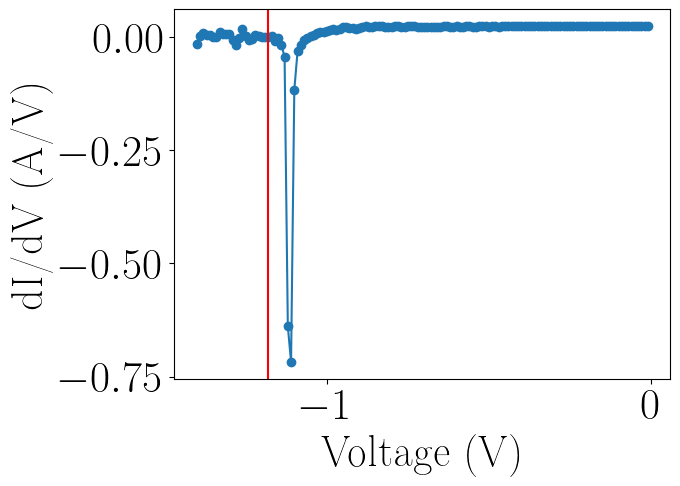

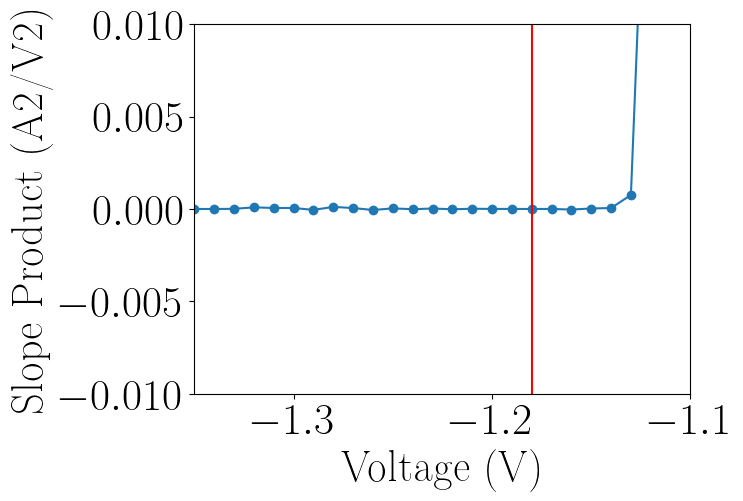

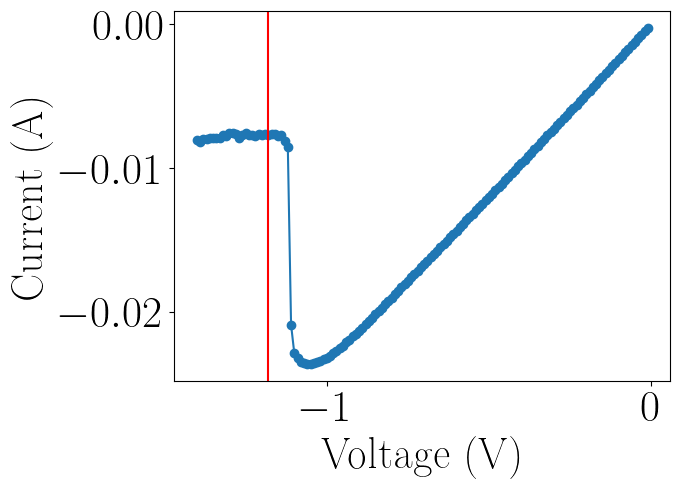

In [5]:
# Recorro cada archivo y calculo V_set con el método de la derivada de cantudo
filas_resultados_derivada = []

for cycle_idx, datos in enumerate(archivos):
    print(f"Procesando archivo: {datos.stem}, índice de ciclo: {cycle_idx+110}")

    # Cargar datos experimentales
    data_set = np.loadtxt(datos)

    voltage = data_set[:, 0]
    current = data_set[:, 1]

    v_reset, i_reset, idx_reset = reset_derivative(voltage, current, cycle_idx+110)

    # Guardo en memoria
    filas_resultados_derivada.append((datos.stem, v_reset))

# Convierto a DataFrame con nombres de columna claros
df_resultados_Cantudo = pd.DataFrame(
    filas_resultados_derivada,
    columns=["Archivo", "V_reset_derivada_V"]
)

# Guardo el “bruto” si lo quieres
results_path = ruta_figuras / "V_reset_experimental_3000_derivada_Cantudo.txt"
df_resultados_Cantudo.to_csv(
    results_path,
    sep="\t",
    index=False,
    header=False,  # si quieres imitar exactamente el txt original sin cabeceras
)

# ------------------------------------------------------------------
# 2) Ordeno por número de ciclo y guardo el archivo ordenado
# ------------------------------------------------------------------

df_resultados_Cantudo["Numero"] = (
    df_resultados_Cantudo["Archivo"].str.extract(r"Cycle_n_(\d+)", expand=False).astype(int)
)

df_resultados_ordenados = df_resultados_Cantudo.sort_values(by="Numero")

df_resultados_ordenados.to_csv(
    ruta_figuras / "V_reset_experimental_3000_derivada_Cantudo.txt",
    sep="\t",
    index=False,
)

In [ ]:
plt.rc("xtick", labelsize=36)
plt.rc("ytick", labelsize=36)

fig, ax = plt.subplots(figsize=(12, 9))

# === Configuración de estilo LaTeX y plot ===
setup_paper_plt(plt, latex=True, scaling=3)
config_ax(ax)

# ---------- EJE X ----------
# Marcas exactas: -1.5 -1.0 −0.5 0.0 0.5 1.0
# ax.set_xticks([250, 500, 750, 1000, 1250])
# ax.set_xticklabels(["250", "500", "750", "1000", "1250"])

ax.set_ylim(-1.55, -0.95)

# ---------- EJE Y ----------
# Marcas en pasos de 0.05 desde 0.2 hasta 0.65
y_ticks = [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0]
ax.set_yticks(y_ticks)


ax.plot(
    df_resultados["Numero"],
    df_resultados["V_reset_derivada_V"],
    "o",
    color="blue",
    label="Derivada A. Lopez"
)

ax.plot(
    df_resultados_Cantudo["Numero"],
    df_resultados_Cantudo["V_reset_derivada_V"],
    "^",
    color="red",
    label="Derivada A.Cantudo",
)

ax.set_xlabel(r"Curve number", fontsize=40)
ax.set_ylabel(r"Reset voltage (\si{\volt})", fontsize=40)
ax.legend(
    labelspacing=0.3,
    handletextpad=0.2,
    handlelength=1.0,
    borderaxespad=0.2,
    loc="best",
)
# ax.set_title("Voltaje de Set experimental vs Simulación")
fig.savefig(
    str(Path.cwd() / "Datos_Experimentales" / "V_Reset")
    + "/V_reset_experimental_3000_ANtonios.pdf",
    dpi=300,
    bbox_inches="tight",
)  # type: ignore
plt.close(fig)
